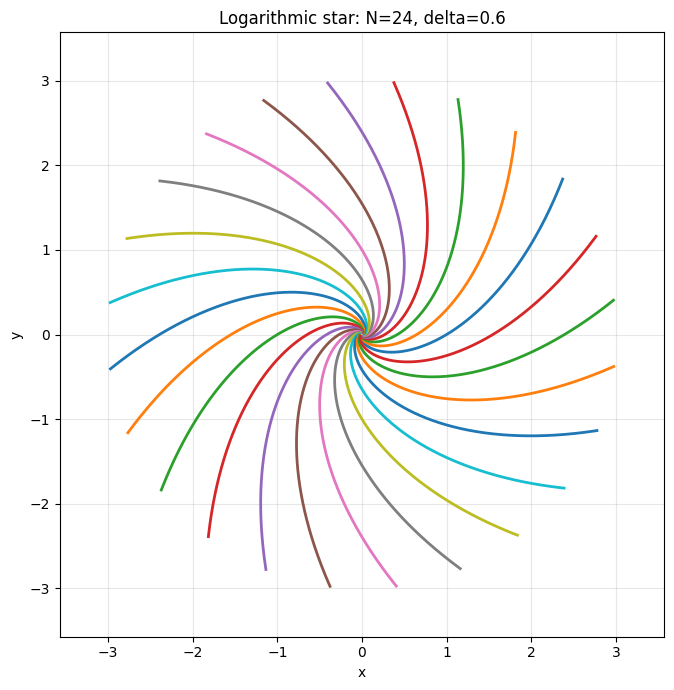

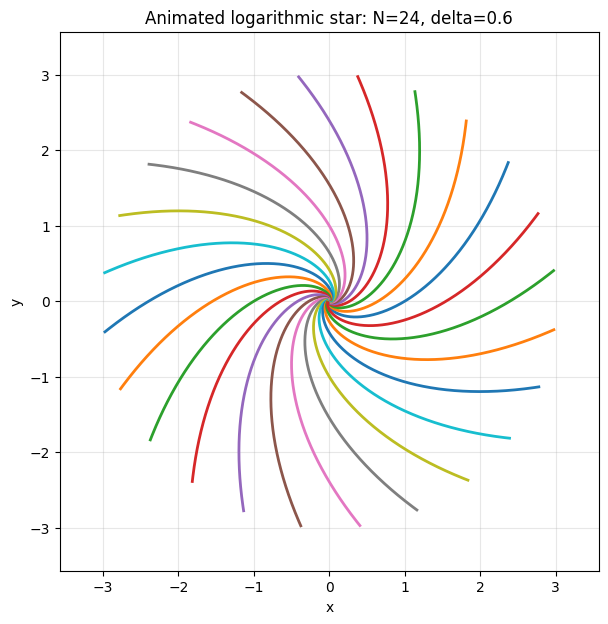

Se guardaron los archivos:
 - logarithmic_star.png
 - logarithmic_star.gif


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# Parámetros de la logarithmic star
# ============================================================
delta = 0.6          # si delta = 0, obtienes rayos
N = 24                # número de ramas
r_min = 0.03
r_max = 3.0
num_points = 1200

# Ángulos beta_k
betas = np.linspace(0, 2*np.pi, N, endpoint=False)

# Parámetro radial en escala logarítmica
r = np.geomspace(r_min, r_max, num_points)

# ============================================================
# Función para construir una rama Gamma_k
# z_k(r) = r * exp(i*(beta_k + delta*log(r)))
# ============================================================
def logarithmic_star_branch(r, beta, delta):
    theta = beta + delta * np.log(r)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

# ============================================================
# GRAFICAR FIGURA ESTÁTICA
# ============================================================
fig, ax = plt.subplots(figsize=(7, 7))

for beta in betas:
    x, y = logarithmic_star_branch(r, beta, delta)
    ax.plot(x, y, linewidth=2)

ax.set_aspect('equal')
ax.set_title(f'Logarithmic star: N={N}, delta={delta}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)

# Ajuste de límites
all_x = []
all_y = []
for beta in betas:
    x, y = logarithmic_star_branch(r, beta, delta)
    all_x.extend(x)
    all_y.extend(y)

margin = 0.1
xmin, xmax = min(all_x), max(all_x)
ymin, ymax = min(all_y), max(all_y)

dx = xmax - xmin
dy = ymax - ymin

ax.set_xlim(xmin - margin*dx, xmax + margin*dx)
ax.set_ylim(ymin - margin*dy, ymax + margin*dy)

plt.tight_layout()
plt.savefig("logarithmic_star.png", dpi=200)
plt.show()

# ============================================================
# HACER GIF
# ============================================================
fig2, ax2 = plt.subplots(figsize=(7, 7))
ax2.set_aspect('equal')
ax2.set_title(f'Animated logarithmic star: N={N}, delta={delta}')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(xmin - margin*dx, xmax + margin*dx)
ax2.set_ylim(ymin - margin*dy, ymax + margin*dy)

# Creamos una línea vacía por cada rama
lines = [ax2.plot([], [], linewidth=2)[0] for _ in betas]

def init():
    for line in lines:
        line.set_data([], [])
    return lines

def update(frame):
    # frame recorre cuántos puntos de cada rama se muestran
    for j, beta in enumerate(betas):
        x, y = logarithmic_star_branch(r[:frame], beta, delta)
        lines[j].set_data(x, y)
    return lines

anim = FuncAnimation(
    fig2,
    update,
    frames=np.linspace(10, num_points, 180, dtype=int),
    init_func=init,
    blit=True,
    interval=40
)

anim.save("logarithmic_star.gif", writer=PillowWriter(fps=25))
plt.show()

print("Se guardaron los archivos:")
print(" - logarithmic_star.png")
print(" - logarithmic_star.gif")